In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import json


In [49]:
# Load the data to examine its structure
file_path = '/content/resnet18_UH_stage1_results.csv'
file_path = '/Users/birdy/Documents/mit-meng-thesis/results/resnet18_UH_stage1_results.csv'
file_path = '/Users/birdy/Documents/mit-meng-thesis/results/resnetAll_WHOI2014_stage1_results.csv'

file_path_18 = '/Users/birdy/Documents/mit-meng-thesis/results/resnet18_UH_stage1_results.csv'
file_path_50 = '/Users/birdy/Documents/mit-meng-thesis/results/resnet50_UH_stage1_results.csv'
file_path_152 = '/Users/birdy/Documents/mit-meng-thesis/results/resnet152_UH_stage1_results.csv'

df_18 = pd.read_csv(file_path_18)
df_50 = pd.read_csv(file_path_50)
df_152 = pd.read_csv(file_path_152)

df_18['per_class_accuracy'] = df_18['per_class_accuracy']/100
df_50['per_class_accuracy'] = df_50['per_class_accuracy']/100
df_152['per_class_accuracy'] = df_152['per_class_accuracy']/100

# Display the first few rows of the dataframe to understand its structure
df_152.head()

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history
0,resnet152-UH-sgd-step-cross_entropy_loss,CrossEntropyLoss(),sgd,step,0.00001,512,0.786315,0.003164,11534.43789,10606.57057,"{'train_loss': [1.1989775263342846, 0.79478898..."
1,resnet152-UH-sgd-step-label_smoothing_loss,label_smoothing,sgd,step,0.00001,512,0.790160,0.003151,11534.43789,10413.48493,"{'train_loss': [1.822605103293801, 1.506423663..."
2,resnet152-UH-sgd-cos-cross_entropy_loss,CrossEntropyLoss(),sgd,cos,0.00000,512,0.775892,0.003148,11534.43789,10560.73438,"{'train_loss': [1.1857352440692883, 0.79118996..."
3,resnet152-UH-sgd-cos-label_smoothing_loss,label_smoothing,sgd,cos,0.00000,512,0.781479,0.003142,11534.43789,10415.14447,"{'train_loss': [1.816852213847383, 1.503106784..."
4,resnet152-UH-sgd-ReduceLROnPlateau-cross_entro...,CrossEntropyLoss(),sgd,ReduceLROnPlateau,0.01000,512,0.704283,0.002852,11534.43789,10562.88301,"{'train_loss': [1.1898108438010906, 0.79764347..."


In [50]:
df = df_18[df_18["model_name"] == "resnet18-UH-adam-step-CrossEntropyLoss()"]
df = pd.concat([df, df_50[df_50["model_name"] == "resnet50-UH-adam-step-cross_entropy_loss"]], ignore_index=True)
df = pd.concat([df, df_152[df_152["model_name"] == "resnet152-UH-adam-step-cross_entropy_loss"]], ignore_index=True)

df["color"] = ["lightgreen", "mediumseagreen", "darkgreen"]
df["size_marker"] = df["MACs"]/2

In [51]:
df

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history,color,size_marker
0,resnet18-UH-adam-step-CrossEntropyLoss(),cross_entropy,adam,step,0.000001,512,0.788898,0.314448,1816.121344,3571.545854,"{'train_loss': [1.0365233352266707, 0.83249209...",lightgreen,908.060672
1,resnet50-UH-adam-step-cross_entropy_loss,CrossEntropyLoss(),adam,step,0.000001,512,0.790460,0.000068,4098.555392,5746.541648,"{'train_loss': [1.0969284439925384, 0.89234060...",mediumseagreen,2049.277696
2,resnet152-UH-adam-step-cross_entropy_loss,CrossEntropyLoss(),adam,step,0.000001,512,0.788538,0.003068,11534.437890,9732.672688,"{'train_loss': [1.1915181784705628, 0.93173118...",darkgreen,5767.218945


# Stage 1

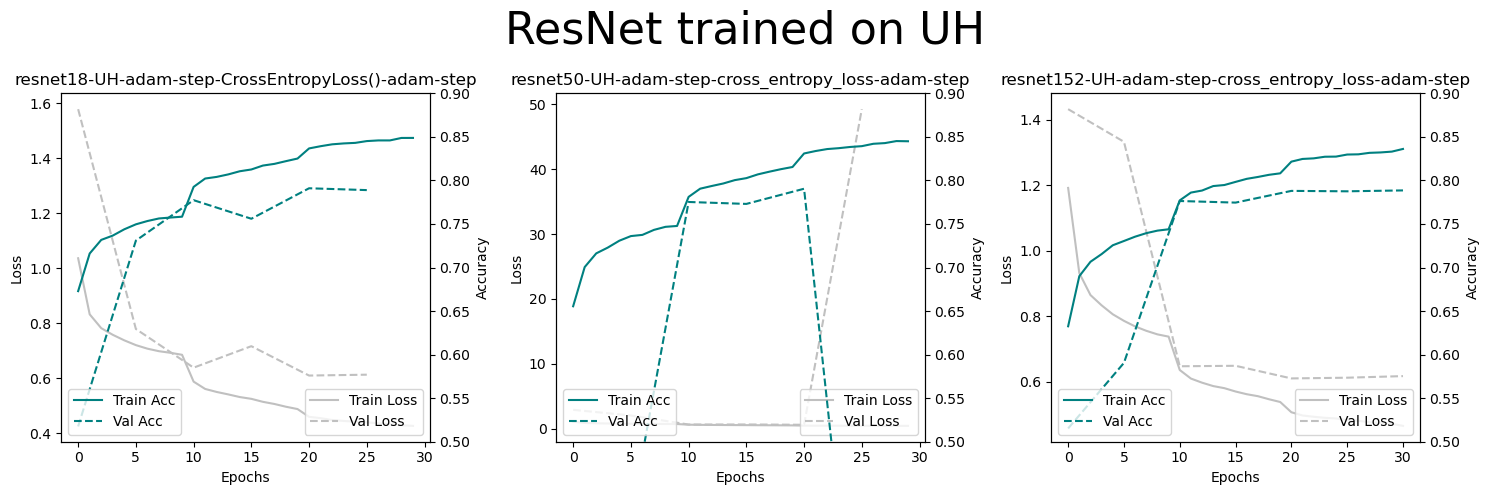

In [52]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
# Plot Accuracy and Loss
for i, ax in zip(range(len(df)), axes):
  history = df['history'][i]
  model_name = df['model_name'][i]
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

  # plot training and validation across epocs
  train_loss = history['train_loss']
  val_loss = history['val_loss']
  val_epochs = history['val_epochs']
  train_acc = history['train_acc']
  val_acc = history['val_acc']

  ax.set_title("Accuracy And Loss During Training")
  ax.plot(train_loss, label='Train Loss', color='silver')
  ax.plot(val_epochs, val_loss, label='Val Loss', color='silver', ls='--')
  # create another axis to plot accuracy on
  ax2 = ax.twinx()
  ax2.plot(train_acc, label='Train Acc', color='teal')
  ax2.plot(val_epochs, val_acc, label='Val Acc', color='teal', ls='--')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Loss')
  ax2.set_ylabel('Accuracy')
  ax2.set_ylim([0.5, .9])
  ax2.legend(loc='lower left')
  ax.legend(loc='lower right')
  opt = df["optimizer"][i]
  sched = df["scheduler"][i]
  ax.set_title(f"{model_name}-{opt}-{sched}")

plt.suptitle("ResNet trained on UH", fontsize=32)
plt.tight_layout()
plt.show()

# Stage 2

In [53]:
file_path_s2 = '/Users/birdy/Documents/mit-meng-thesis/results/ResnetAll_UH_stage2_freeze_results.csv'
df_s2 = pd.read_csv(file_path_s2)
df_s2["size_marker"] = df_s2["MACs"]/2
df_s2

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history,color,type,size_marker
0,resnet18-UH-freeze-adam-step,cross_entropy,adam,step,0.000001,512,0.657245,0.200197,1816.121344,4522.594911,"{'train_loss': [1.6044251240550302, 1.21633992...",lightgreen,18,908.060672
1,resnet50-UH-freeze,cross_entropy,adam,step,0.000001,512,0.658807,0.208842,4098.555392,4117.917785,"{'train_loss': [1.5377394487007001, 1.21165628...",mediumseagreen,50,2049.277696
2,resnet152-UH-freeze,cross_entropy,adam,step,0.000001,512,0.655713,0.216539,11534.437890,6299.648485,"{'train_loss': [1.505290404380294, 1.209925532...",darkgreen,152,5767.218945


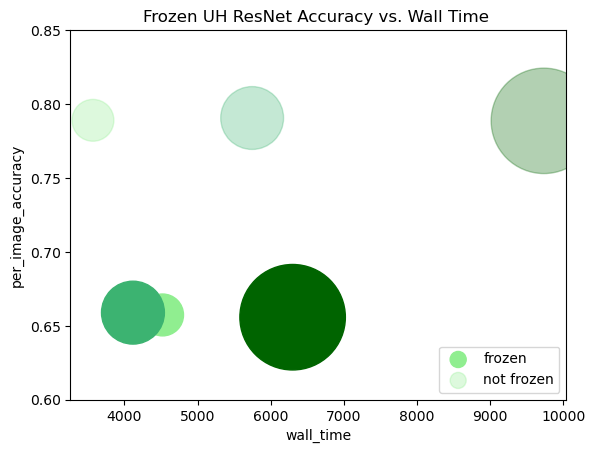

In [55]:
# plot resnet18-freeze, 50, 152 per_image_accuracy vs wall_time
fig, ax = plt.subplots()
df_s2.iloc[:3].plot("wall_time", "per_image_accuracy", kind='scatter', ax=ax, s="size_marker", alpha=1, color=df_s2.iloc[:3]["color"], label="frozen")
df.plot("wall_time", "per_image_accuracy", kind='scatter', ax=ax, s="size_marker", alpha=0.3, color=df["color"], label="not frozen")
# ax.set_xlim([6000, 16500])
ax.set_ylim([0.6, 0.85])
ax.legend(loc="lower right", markerscale=0.2)
ax.set_title("Frozen UH ResNet Accuracy vs. Wall Time ")
plt.show()

# Stage 2 - Dropout

In [56]:
file_path_s2 = '/Users/birdy/Documents/mit-meng-thesis/results/ResnetAll_UH_stage2_dropout_results.csv'
df_s2 = pd.read_csv(file_path_s2)
df_s2["size_marker"] = df_s2["MACs"]/2
df_s2

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history,color,type,size_marker
0,resnet18-UH-dropout0.1,cross_entropy,adam,step,0.000001,512,0.769945,0.256530,1816.121344,4982.626276,"{'train_loss': [1.6198424711782187, 1.16148065...",NaN,NaN,908.060672
1,resnet18-UH-dropout0.3,cross_entropy,adam,step,0.000001,512,0.737955,0.006757,1816.121344,4958.215716,"{'train_loss': [1.6677363677928208, 1.18096663...",NaN,NaN,908.060672
2,resnet18-UH-dropout0.5,cross_entropy,adam,step,0.000001,512,0.751922,0.233171,1816.121344,4911.101142,"{'train_loss': [1.7647524332692934, 1.20474357...",NaN,NaN,908.060672
3,resnet50-UH-dropout0.1,cross_entropy,adam,step,0.000001,512,0.746456,0.220813,4098.555392,6405.548501,"{'train_loss': [1.6369452947710532, 1.22085344...",NaN,NaN,2049.277696
4,resnet50-UH-dropout0.3,cross_entropy,adam,step,0.000001,512,0.722876,0.006757,4098.555392,6394.741048,"{'train_loss': [1.6959134653277044, 1.23691326...",NaN,NaN,2049.277696
5,resnet50-UH-dropout0.5,cross_entropy,adam,step,0.000001,512,0.715457,0.194281,4098.555392,6387.209148,"{'train_loss': [1.787849800724244, 1.266555347...",NaN,NaN,2049.277696
6,TEMPresnet152-UH-dropout0.1,cross_entropy,adam,step,0.000001,256,0.731068,0.145113,11534.315010,19143.745450,"{'train_loss': [0.6977349471025382, 0.42362719...",NaN,NaN,5767.157505
7,TEMPresnet152-UH-dropout0.3,cross_entropy,adam,step,0.000001,256,0.730839,0.160256,11534.315010,19102.262500,"{'train_loss': [0.7280070153042278, 0.44110746...",NaN,NaN,5767.157505
8,TEMPresnet152-UH-dropout0.5,cross_entropy,adam,step,0.000001,256,0.724848,0.140030,11534.315010,19087.253170,"{'train_loss': [0.7635995842240796, 0.46735787...",NaN,NaN,5767.157505


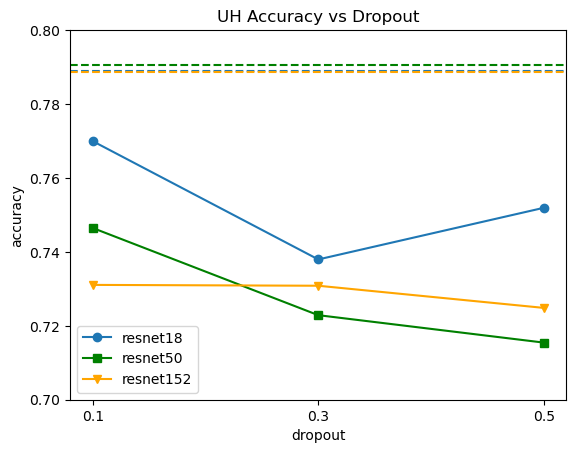

In [57]:
fig, ax = plt.subplots()
dropouts = [0.1, 0.3, 0.5]
ax.plot(dropouts, df_s2.loc[0:2]['per_image_accuracy'], marker='o', label="resnet18")
ax.plot(dropouts, df_s2.loc[3:5]['per_image_accuracy'], marker='s', label="resnet50", color='green')
ax.plot(dropouts, df_s2.loc[6:8]['per_image_accuracy'], marker='v', label="resnet152", color="orange")
ax.axhline(df.loc[0]['per_image_accuracy'], color='tab:blue', linestyle='--')
ax.axhline(df.loc[1]['per_image_accuracy'], color='green', linestyle='--')
ax.axhline(df.loc[2]['per_image_accuracy'], color='orange', linestyle='--')
ax.set_xticks([0.1, 0.3, 0.5])
ax.set_ylabel("accuracy")
ax.set_xlabel("dropout")
ax.set_ylim([0.7, 0.8])
ax.legend()
ax.set_title("UH Accuracy vs Dropout")
plt.show()

# Stage 3 - Augmentations

In [58]:
file_path_s3 = '/Users/birdy/Documents/mit-meng-thesis/results/ResnetAll_UH_stage3_results.csv'
df_s3 = pd.read_csv(file_path_s3)
df_s3["size_marker"] = df_s3["MACs"]/2

In [59]:
df_s3

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history,color,type,size_marker
0,resnet18-UH-train_padToSize,cross_entropy,adam,step,0.000001,512,0.775712,0.280238,1816.121344,3007.851067,"{'train_loss': [1.028310005928714, 0.807366591...",NaN,NaN,908.060672
1,resnet18-UH-train_augmix,cross_entropy,adam,step,0.000001,512,0.778355,0.300724,1816.121344,25834.043250,"{'train_loss': [1.2061763988063232, 0.99138467...",NaN,NaN,908.060672
2,resnet50-UH-train_padToSize,cross_entropy,adam,step,0.000001,512,0.778055,0.271896,4098.555392,4846.997414,"{'train_loss': [1.126702520203536, 0.871656780...",NaN,NaN,2049.277696
3,resnet50-UH-train_augmix,cross_entropy,adam,step,0.000001,512,0.779346,0.294172,4098.555392,27162.136290,"{'train_loss': [1.2687300608041243, 1.04349887...",NaN,NaN,2049.277696
4,resnet152-UH-train_padToSize,cross_entropy,adam,step,0.000001,512,0.777694,0.270583,11534.437890,9481.663886,"{'train_loss': [1.1968106229549629, 0.89429550...",NaN,NaN,5767.218945
5,TEMPresnet152-UH-train_augmix,cross_entropy,adam,step,0.000001,512,0.758355,0.300724,11534.315010,42834.043250,"{'train_loss': [1.2061763988063232, 0.99138467...",NaN,NaN,5767.157505


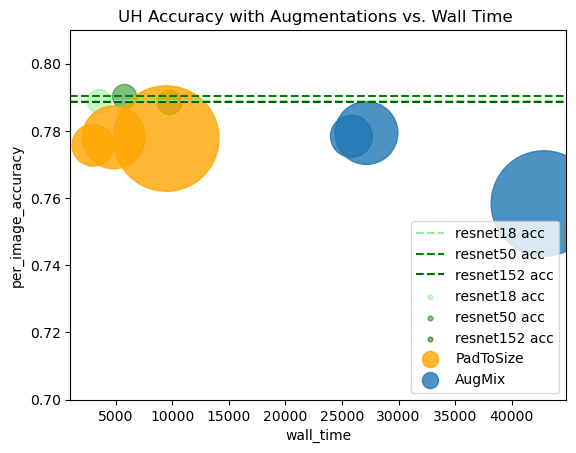

In [60]:
pad_idxs = [0, 2, 4]
aug_idxs = [1, 3, 5]
# plot resnet18-freeze, 50, 152 per_image_accuracy vs wall_time
fig, ax = plt.subplots()

# Plain ResNet Accuracy
ax.axhline(df.loc[0]['per_image_accuracy'], color='lightgreen', linestyle='--', label="resnet18 acc")
ax.axhline(df.loc[1]['per_image_accuracy'], color='green', linestyle='--', label="resnet50 acc")
ax.axhline(df.loc[2]['per_image_accuracy'], color='darkgreen', linestyle='--', label="resnet152 acc")

ax.scatter(df.loc[0]['wall_time'], df.loc[0]['per_image_accuracy'], s=300, alpha = 0.5, color='lightgreen', label="resnet18 acc")
ax.scatter(df.loc[1]['wall_time'], df.loc[1]['per_image_accuracy'], s=300,alpha = 0.5, color='green', label="resnet50 acc")
ax.scatter(df.loc[2]['wall_time'], df.loc[2]['per_image_accuracy'], s=300, alpha = 0.5, color='darkgreen', label="resnet152 acc")

df_s3.iloc[pad_idxs].plot("wall_time", "per_image_accuracy", kind='scatter', ax=ax, s="size_marker", alpha=.8, color='orange', label="PadToSize")
df_s3.iloc[aug_idxs].plot("wall_time", "per_image_accuracy", kind='scatter', ax=ax, s="size_marker", alpha=.8, color='tab:blue', label="AugMix")
# df.plot("wall_time", "per_image_accuracy", kind='scatter', ax=ax, s="size_marker", alpha=0.3, color='green', label="No Aug")
# ax.set_xlim([6000, 16500])

ax.set_ylim([0.7, 0.81])
ax.legend(loc="lower right", markerscale=0.2)
ax.set_title("UH Accuracy with Augmentations vs. Wall Time ")
plt.show()

## Single Plots 

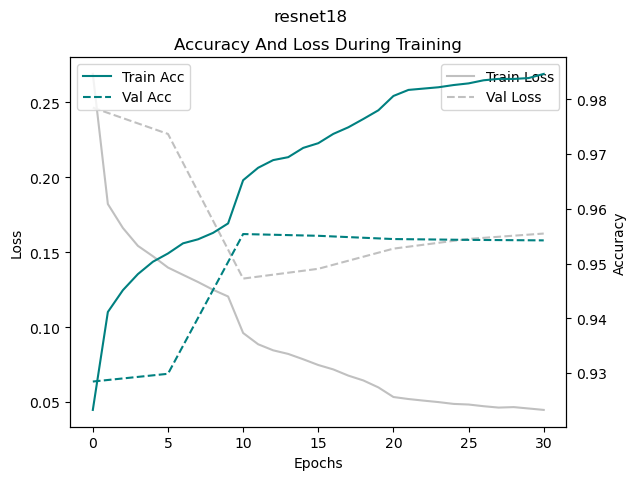

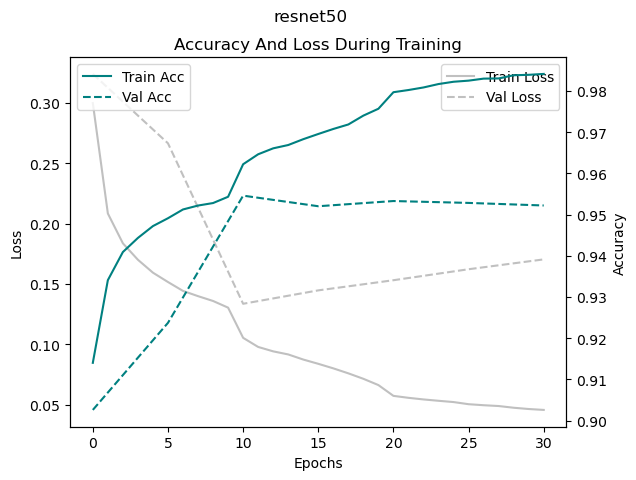

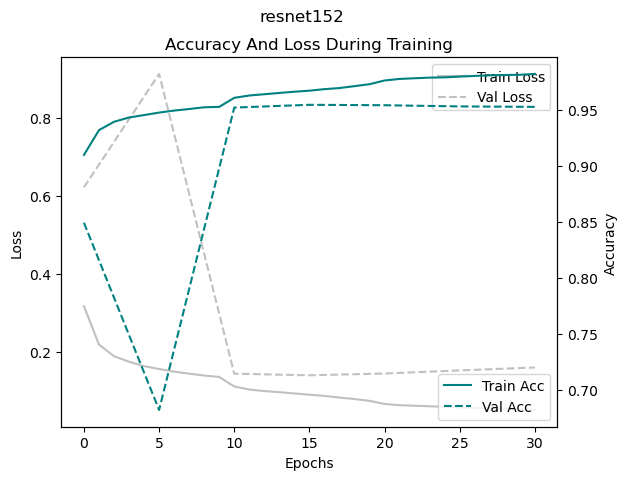

In [8]:
# Plot Accuracy and Loss
for i in range(len(df)):
  history = df['history'][i]
  model_name = df['model_name'][i]
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

  # plot training and validation across epocs
  train_loss = history['train_loss']
  val_loss = history['val_loss']
  val_epochs = history['val_epochs']
  train_acc = history['train_acc']
  val_acc = history['val_acc']

  fig, ax = plt.subplots()
  ax.set_title("Accuracy And Loss During Training")
  ax.plot(train_loss, label='Train Loss', color='silver')
  ax.plot(val_epochs, val_loss, label='Val Loss', color='silver', ls='--')
  # create another axis to plot accuracy on
  ax2 = ax.twinx()
  ax2.plot(train_acc, label='Train Acc', color='teal')
  ax2.plot(val_epochs, val_acc, label='Val Acc', color='teal', ls='--')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Loss')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  ax.legend()
  plt.suptitle(f"{model_name}")
  plt.show()

# Model Comparison Plots

## Accuracy of models

In [ ]:
df[['model_name', 'per_image_accuracy']].sort_values(by='per_image_accuracy', ascending=False)

,model_name,per_image_accuracy
7,resnet18-UH-adam-step-CrossEntropyLoss(),0.790130
6,resnet18-UH-adam-step-CrossEntropyLoss(),0.788898
3,resnet18-UH-sgd-cos-CrossEntropyLoss(),0.787817
12,resnet18-UH-adamw-step-CrossEntropyLoss(),0.786946
0,resnet18-UH-sgd-step-CrossEntropyLoss(),0.784903
2,resnet18-UH-sgd-cos-CrossEntropyLoss(),0.782921
9,resnet18-UH-adam-cos-CrossEntropyLoss(),0.780728
8,resnet18-UH-adam-cos-CrossEntropyLoss(),0.777905
15,resnet18-UH-adamw-cos-CrossEntropyLoss(),0.772708
14,resnet18-UH-adamw-cos-CrossEntropyLoss(),0.772528


## Per-Image vs Per-Class

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


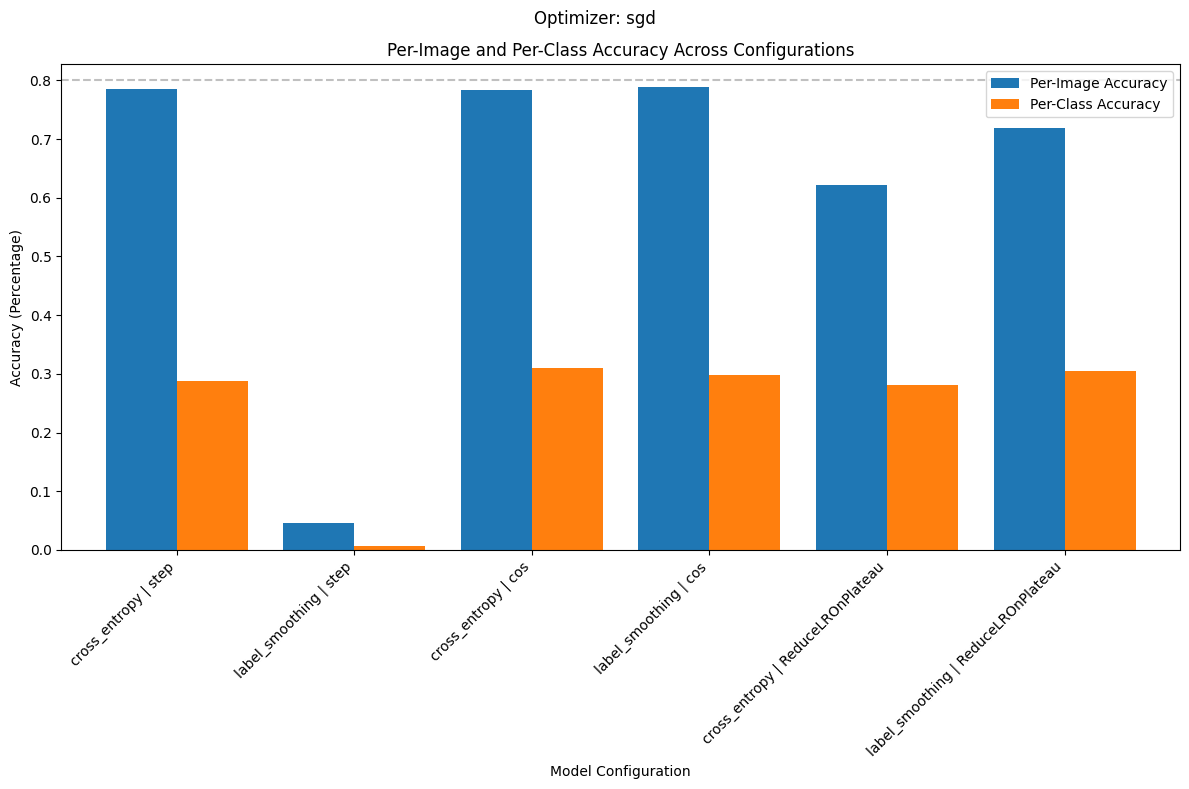

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


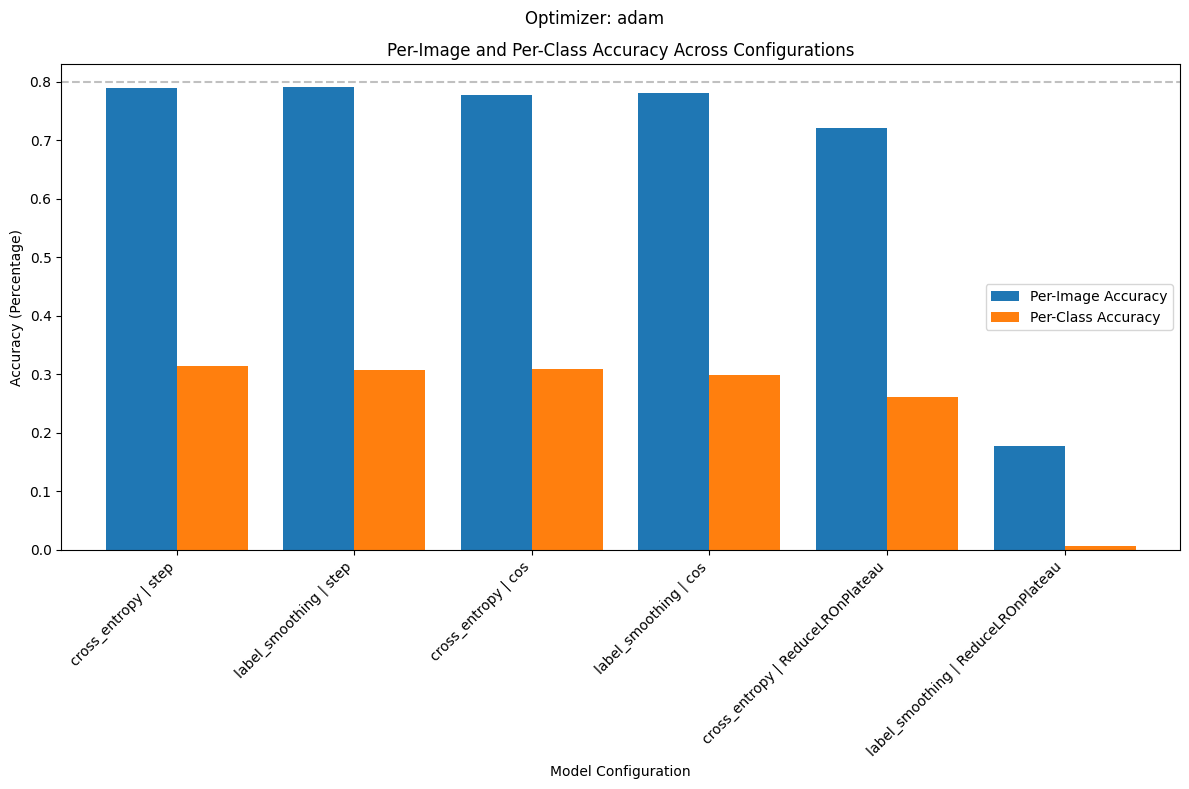

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


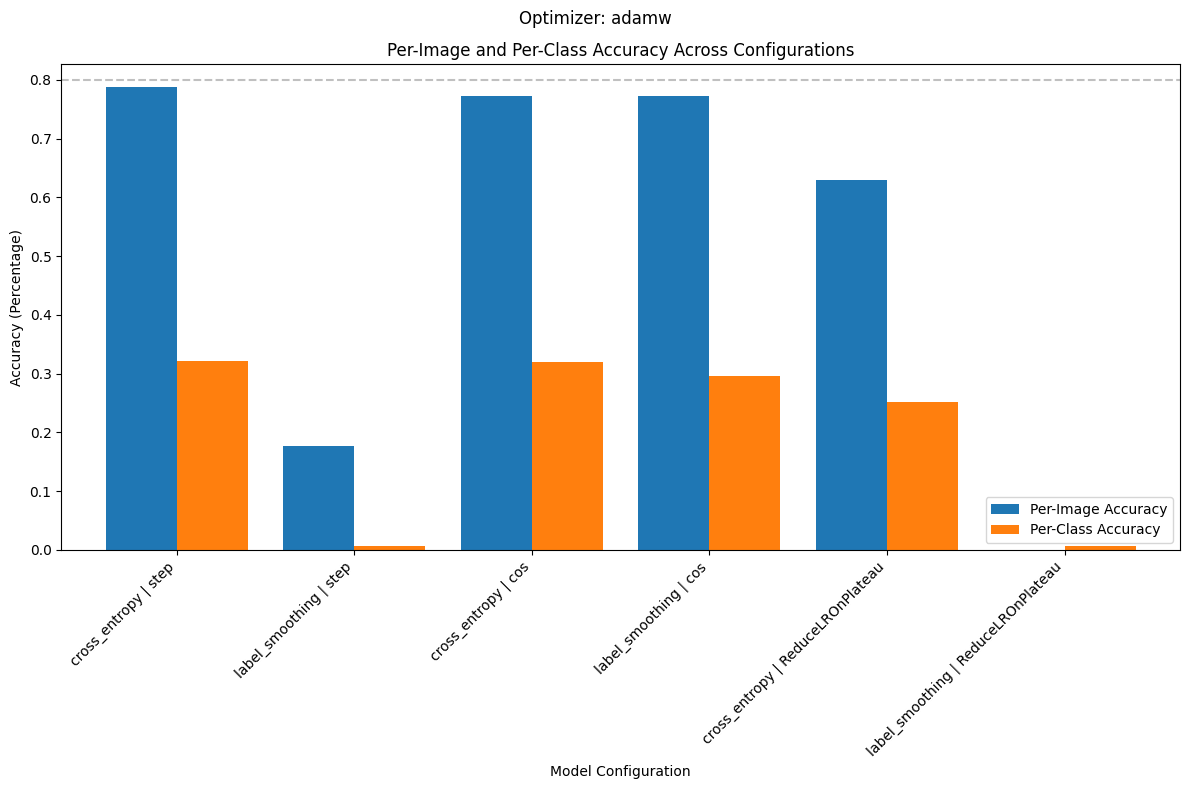

In [ ]:
# organize by optmizer still

for opt in df['optimizer'].unique():
  df_opt = df[df['optimizer'] == opt]
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']
  acc_data = df_opt[['Configuration','per_image_accuracy', 'per_class_accuracy']].set_index('Configuration')

  fig, ax = plt.subplots()
  # bar chart of accuracy and per class accuracy
  acc_data.plot(kind='bar', width=0.8, figsize=(12, 8), ax=ax)
  plt.title("Per-Image and Per-Class Accuracy Across Configurations")
  plt.xlabel("Model Configuration")
  plt.ylabel("Accuracy (Percentage)")
  plt.xticks(rotation=45, ha="right")
  plt.legend(["Per-Image Accuracy", "Per-Class Accuracy"])
  plt.suptitle(f"Optimizer: {opt}")
  plt.tight_layout()
  ax.axhline(y=.80, color='silver', linestyle='--')
  plt.show()


## Wall Time

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


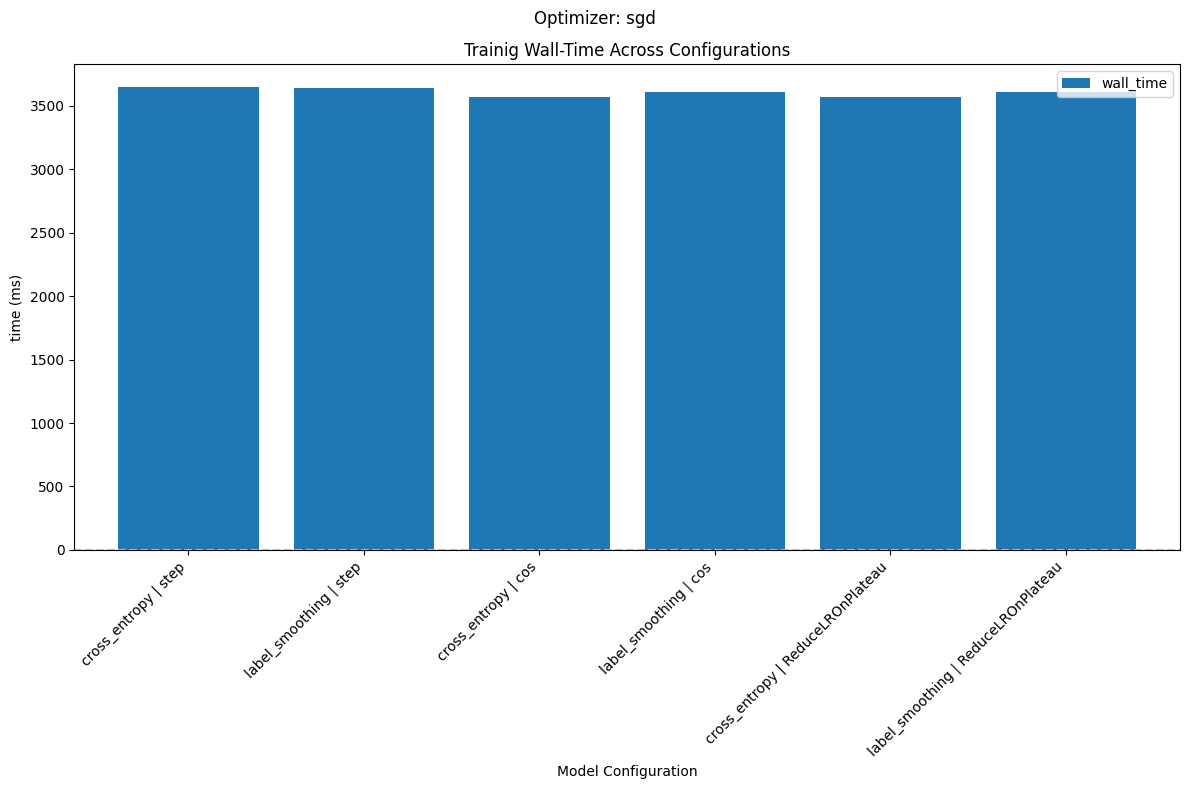

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


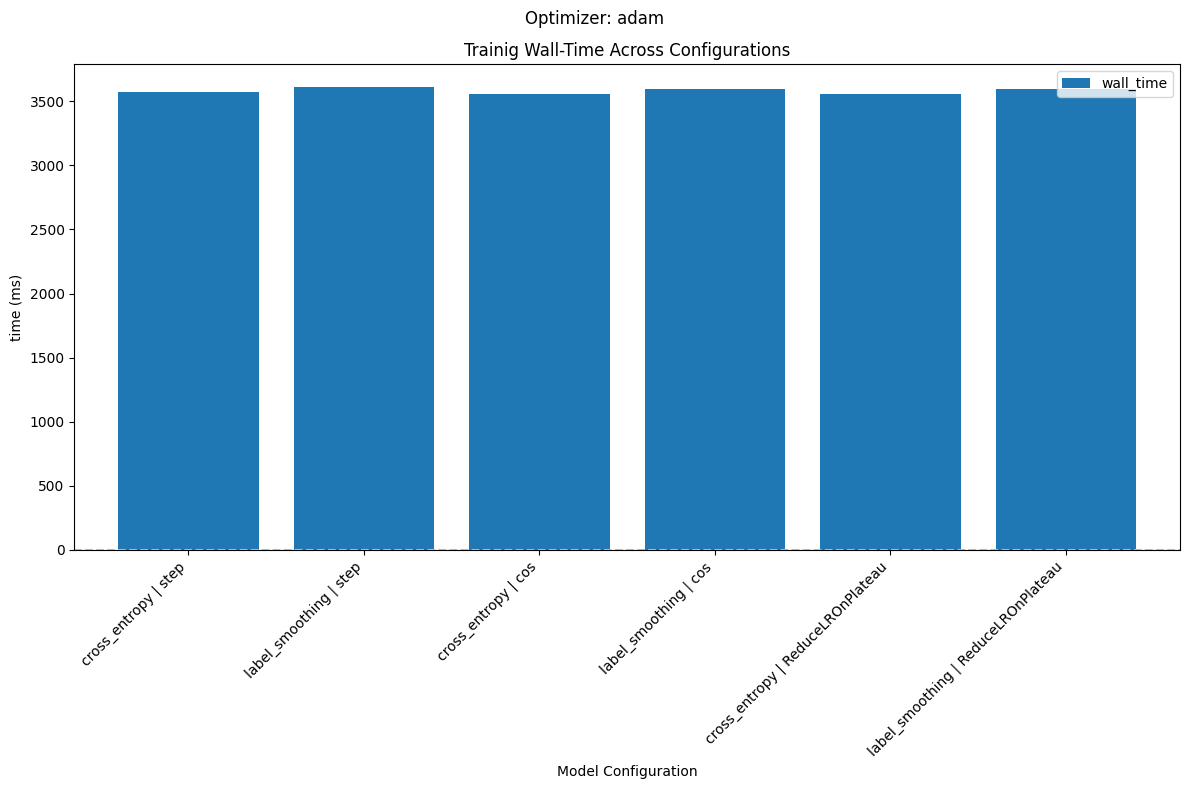

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


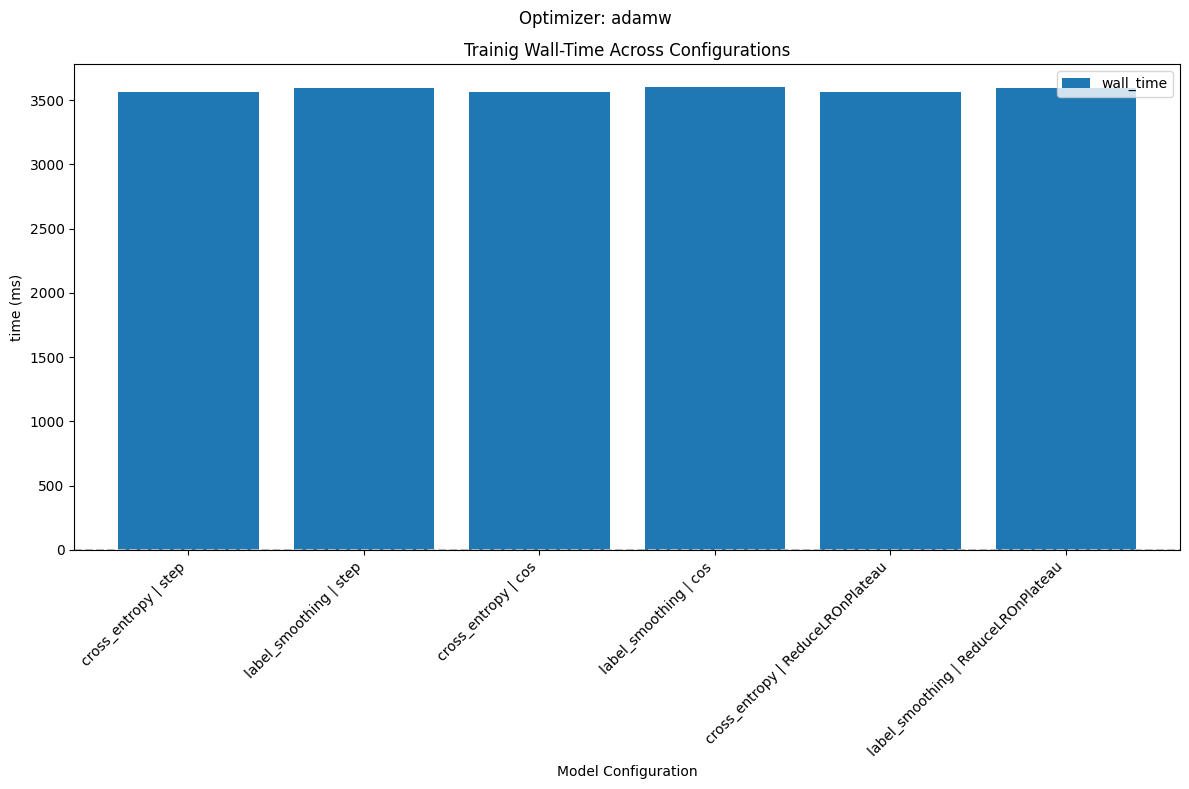

In [ ]:
# organize by optmizer still

for opt in df['optimizer'].unique():
  df_opt = df[df['optimizer'] == opt]
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']
  acc_data = df_opt[['Configuration','wall_time']].set_index('Configuration')

  fig, ax = plt.subplots()
  # bar chart of accuracy and per class accuracy
  acc_data.plot(kind='bar', width=0.8, figsize=(12, 8), ax=ax)
  plt.title("Trainig Wall-Time Across Configurations")
  plt.xlabel("Model Configuration")
  plt.ylabel("time (ms)")
  plt.xticks(rotation=45, ha="right")
  plt.suptitle(f"Optimizer: {opt}")
  plt.tight_layout()
  ax.axhline(y=.80, color='silver', linestyle='--')
  plt.show()